In [22]:
import numpy as np
import time

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score
from scipy.optimize import linear_sum_assignment
from sklearn.neural_network import MLPClassifier

import tensorflow as tf

from sklearn.preprocessing import StandardScaler


### 1. CARGAR DATASET

In [2]:
datos = np.load("datos/har_dataset.npz")

X_train = datos["X_train"]
y_train = datos["y_train"]

X_test = datos["X_test"]
y_test = datos["y_test"]


print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

X_train: (7352, 561)
X_test : (2947, 561)


### 2. NORMALIZAR

In [3]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Kmeans y 4. PREDICCIoN K-MEANS

In [4]:
print("\nEntrenando K-Means...")

inicio = time.perf_counter()

kmeans = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

kmeans.fit(X_train_scaled)

tiempo_kmeans_entrenamiento = time.perf_counter() - inicio


Entrenando K-Means...


In [5]:
inicio = time.perf_counter()

clusters_test = kmeans.predict(X_test_scaled)

tiempo_kmeans_prediccion = time.perf_counter() - inicio

### 5. MAPEAR CLUSTERS → ACTIVIDADES

In [6]:
def obtener_mapeo_clusters(y_real, clusters):

    clases = np.unique(y_real)
    clusters_unicos = np.unique(clusters)

    matriz = np.zeros(
        (len(clases), len(clusters_unicos)),
        dtype=int
    )

    for i, clase in enumerate(clases):
        for j, cluster in enumerate(clusters_unicos):

            matriz[i, j] = np.sum(
                (y_real == clase) &
                (clusters == cluster)
            )

    filas, columnas = linear_sum_assignment(
        -matriz
    )

    mapeo = {}

    for fila, columna in zip(filas, columnas):
        mapeo[clusters_unicos[columna]] = clases[fila]

    return mapeo


mapeo = obtener_mapeo_clusters(
    y_train,
    kmeans.labels_
)


# 6. CONVERTIR CLUSTERS EN ACTIVIDADES

In [7]:
y_pred_kmeans = np.array([
    mapeo.get(cluster, -1)
    for cluster in clusters_test
])


accuracy_kmeans = accuracy_score(
    y_test,
    y_pred_kmeans
)

# 7. SVM

In [8]:
print("\nEntrenando SVM...")

inicio = time.perf_counter()

svm = SVC(
    kernel="rbf",
    C=10,
    gamma="scale"
)

svm.fit(
    X_train_scaled,
    y_train
)

tiempo_svm_entrenamiento = time.perf_counter() - inicio


Entrenando SVM...


In [9]:
inicio = time.perf_counter()

y_pred_svm = svm.predict(X_test_scaled)

tiempo_svm_prediccion = time.perf_counter() - inicio


accuracy_svm = accuracy_score(
    y_test,
    y_pred_svm
)

### 9. RESULTADOS

In [ ]:
print("\n========================================")
print("RESULTADOS")
print("========================================")




RESULTADOS

K-MEANS
Accuracy:              0.5514
Tiempo entrenamiento:  3.0023 s
Tiempo predicción:     0.0071 s

SVM
Accuracy:              0.9549
Tiempo entrenamiento:  1.3201 s
Tiempo predicción:     1.3972 s


In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

X_train_2d = pca.fit_transform(X_train_scaled)

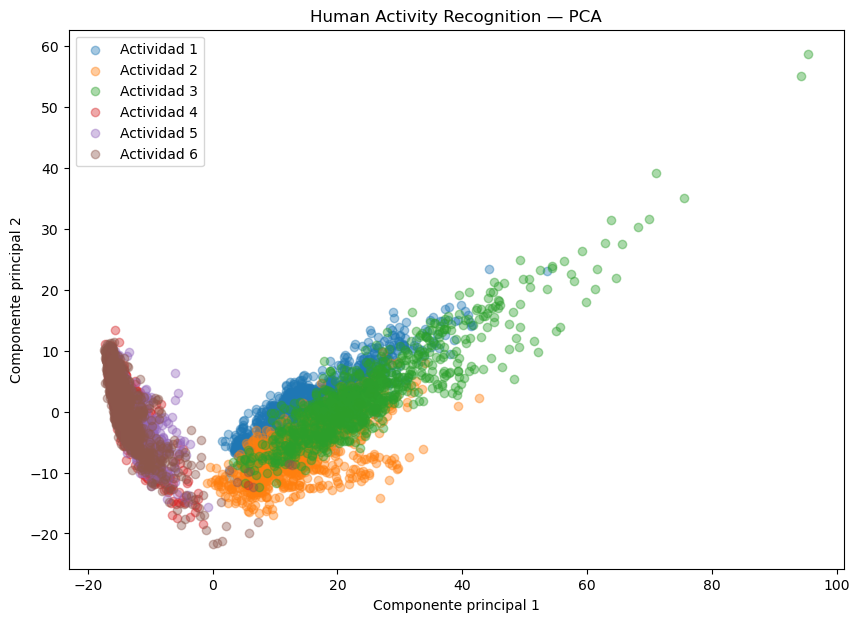

In [12]:
plt.figure(figsize=(10, 7))

for actividad in np.unique(y_train):

    indices = y_train == actividad

    plt.scatter(
        X_train_2d[indices, 0],
        X_train_2d[indices, 1],
        alpha=0.4,
        label=f"Actividad {actividad}"
    )

plt.xlabel("Componente principal 1")
plt.ylabel("Componente principal 2")
plt.title("Human Activity Recognition — PCA")
plt.legend()
plt.show()

In [14]:
mlp = MLPClassifier(
    hidden_layer_sizes=(100,),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    batch_size="auto",
    learning_rate="constant",
    learning_rate_init=0.001,
    max_iter=100,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=10
)

In [15]:
print("\nEntrenando MLP...")

inicio = time.perf_counter()

mlp.fit(
    X_train_scaled,
    y_train
)

tiempo_entrenamiento = time.perf_counter() - inicio


Entrenando MLP...


In [16]:
inicio = time.perf_counter()

y_pred = mlp.predict(X_test_scaled)

tiempo_prediccion = time.perf_counter() - inicio

In [17]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

In [18]:
print("\n========================================")
print("RESULTADOS MLP")
print("========================================")

print(f"Accuracy:              {accuracy:.4f}")
print(f"Tiempo entrenamiento:  {tiempo_entrenamiento:.4f} s")
print(f"Tiempo predicción:     {tiempo_prediccion:.4f} s")

print(f"\nIteraciones realizadas: {mlp.n_iter_}")


RESULTADOS MLP
Accuracy:              0.9410
Tiempo entrenamiento:  0.7799 s
Tiempo predicción:     0.0040 s

Iteraciones realizadas: 19


In [23]:
X_train_cnn = X_train_scaled.reshape(
    X_train_scaled.shape[0],
    X_train_scaled.shape[1],
    1
)

X_test_cnn = X_test_scaled.reshape(
    X_test_scaled.shape[0],
    X_test_scaled.shape[1],
    1
)

In [24]:
modelo = tf.keras.Sequential([

    tf.keras.layers.Conv1D(
        filters=32,
        kernel_size=5,
        activation="relu",
        input_shape=(561, 1)
    ),

    tf.keras.layers.MaxPooling1D(
        pool_size=2
    ),

    tf.keras.layers.Conv1D(
        filters=64,
        kernel_size=5,
        activation="relu"
    ),

    tf.keras.layers.MaxPooling1D(
        pool_size=2
    ),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(
        64,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        6,
        activation="softmax"
    )
])


modelo.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


modelo.summary()

c:\Users\Jpose75\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 557, 32)        │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 278, 32)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 274, 64)        │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 137, 64)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8768)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       561,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 572,102 (2.18 MB)

 Trainable params: 572,102 (2.18 MB)

 Non-trainable params: 0 (0.00 B)

In [25]:
print("\nEntrenando CNN...")

inicio = time.perf_counter()

historial = modelo.fit(
    X_train_cnn,
    y_train - 1,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

tiempo_entrenamiento = time.perf_counter() - inicio


Entrenando CNN...
Epoch 1/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - accuracy: 0.8056 - loss: 0.4768 - val_accuracy: 0.9457 - val_loss: 0.1277
Epoch 2/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9471 - loss: 0.1446 - val_accuracy: 0.9497 - val_loss: 0.1104
Epoch 3/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9702 - loss: 0.0804 - val_accuracy: 0.9742 - val_loss: 0.0651
Epoch 4/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9770 - loss: 0.0681 - val_accuracy: 0.9742 - val_loss: 0.0742
Epoch 5/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9796 - loss: 0.0552 - val_accuracy: 0.9783 - val_loss: 0.0658
Epoch 6/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9855 - loss: 0.0410 - val_accuracy: 0.9674 - val_loss: 0.0810
Epoch 7/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9887 - loss: 0.0315 - val_accuracy: 0.9728 - val_loss: 0.0642
Epoch 8/30
104/104 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9914 - loss

In [26]:
inicio = time.perf_counter()

predicciones = modelo.predict(
    X_test_cnn,
    verbose=0
)

tiempo_prediccion = time.perf_counter() - inicio


In [27]:
y_pred = np.argmax(
    predicciones,
    axis=1
) + 1

In [28]:
accuracy = accuracy_score(
    y_test,
    y_pred
)


In [ ]:
print("\n========================================")
print("RESULTADOS CNN")
print("========================================")

print(f"Accuracy:              {accuracy:.4f}")
print(f"Tiempo entrenamiento:  {tiempo_entrenamiento:.4f} s")
print(f"Tiempo predicción:     {tiempo_prediccion:.4f} s")

print("\nK-MEANS")
print(f"Accuracy:              {accuracy_kmeans:.4f}")
print(f"Tiempo entrenamiento:  {tiempo_kmeans_entrenamiento:.4f} s")
print(f"Tiempo predicción:     {tiempo_kmeans_prediccion:.4f} s")

print("\nSVM")
print(f"Accuracy:              {accuracy_svm:.4f}")
print(f"Tiempo entrenamiento:  {tiempo_svm_entrenamiento:.4f} s")
print(f"Tiempo predicción:     {tiempo_svm_prediccion:.4f} s")


RESULTADOS CNN
Accuracy:              0.8753
Tiempo entrenamiento:  26.1572 s
Tiempo predicción:     0.3046 s

K-MEANS
Accuracy:              0.5514
Tiempo entrenamiento:  3.0023 s
Tiempo predicción:     0.0071 s

SVM
Accuracy:              0.9549
Tiempo entrenamiento:  1.3201 s
Tiempo predicción:     1.3972 s


In [ ]:
import numpy as np
import time

import tensorflow as tf

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)


# ============================================================
# 1. CARGAR DATASET
# ============================================================

datos = np.load("datos/gatos_perros_dataset.npz")

X_train = datos["X_train"]
y_train = datos["y_train"]

X_val = datos["X_val"]
y_val = datos["y_val"]

X_test = datos["X_test"]
y_test = datos["y_test"]


print("X_train:", X_train.shape)
print("X_val  :", X_val.shape)
print("X_test :", X_test.shape)


# ============================================================
# 2. PREPARAR IMÁGENES PARA CNN
# ============================================================

# Actualmente:
#
# X_train = (14000, 784)
#
# CNN necesita:
#
# X_train = (14000, 28, 28, 1)

X_train_cnn = X_train.reshape(
    -1,
    28,
    28,
    1
)

X_val_cnn = X_val.reshape(
    -1,
    28,
    28,
    1
)

X_test_cnn = X_test.reshape(
    -1,
    28,
    28,
    1
)


# ============================================================
# 3. CREAR CNN
# ============================================================

modelo = tf.keras.Sequential([

    # Primera capa convolucional
    tf.keras.layers.Conv2D(
        filters=32,
        kernel_size=(3, 3),
        activation="relu",
        input_shape=(28, 28, 1)
    ),

    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),


    # Segunda capa convolucional
    tf.keras.layers.Conv2D(
        filters=64,
        kernel_size=(3, 3),
        activation="relu"
    ),

    tf.keras.layers.MaxPooling2D(
        pool_size=(2, 2)
    ),


    # Convertir mapas de características a vector
    tf.keras.layers.Flatten(),


    # Capa completamente conectada
    tf.keras.layers.Dense(
        128,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.5),


    # Salida binaria
    tf.keras.layers.Dense(
        1,
        activation="sigmoid"
    )
])


# ============================================================
# 4. COMPILAR
# ============================================================

modelo.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


modelo.summary()


# ============================================================
# 5. ENTRENAMIENTO
# ============================================================

print("\nEntrenando CNN...")

inicio = time.perf_counter()

historial = modelo.fit(
    X_train_cnn,
    y_train,
    validation_data=(X_val_cnn, y_val),
    epochs=15,
    batch_size=64,
    verbose=1
)

tiempo_entrenamiento = time.perf_counter() - inicio


# ============================================================
# 6. PREDICCIÓN
# ============================================================

inicio = time.perf_counter()

probabilidades = modelo.predict(
    X_test_cnn,
    verbose=0
)

tiempo_prediccion = time.perf_counter() - inicio


# ============================================================
# 7. CONVERTIR PROBABILIDADES EN CLASES
# ============================================================

y_pred = (
    probabilidades.ravel() >= 0.5
).astype(int)


# ============================================================
# 8. MÉTRICAS
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

matriz = confusion_matrix(
    y_test,
    y_pred
)


# ============================================================
# 9. RESULTADOS
# ============================================================



X_train: (13993, 784)
X_val  : (2998, 784)
X_test : (2999, 784)


c:\Users\Jpose75\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       204,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 223,873 (874.50 KB)

 Trainable params: 223,873 (874.50 KB)

 Non-trainable params: 0 (0.00 B)


Entrenando CNN...
Epoch 1/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.8090 - loss: 0.4128 - val_accuracy: 0.8542 - val_loss: 0.3402
Epoch 2/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8626 - loss: 0.3211 - val_accuracy: 0.8519 - val_loss: 0.3320
Epoch 3/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8727 - loss: 0.2932 - val_accuracy: 0.8732 - val_loss: 0.3023
Epoch 4/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8876 - loss: 0.2737 - val_accuracy: 0.8776 - val_loss: 0.2948
Epoch 5/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8907 - loss: 0.2617 - val_accuracy: 0.8699 - val_loss: 0.2974
Epoch 6/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.8979 - loss: 0.2415 - val_accuracy: 0.8689 - val_loss: 0.3084
Epoch 7/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.9041 - loss: 0.2309 - val_accuracy: 0.8779 - val_loss: 0.2905
Epoch 8/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.9079 - loss: 0.2159

In [ ]:
print("\n========================================")
print("RESULTADOS CNN")
print("========================================")

print(f"Accuracy:              {accuracy:.4f}")
print(f"Precision:             {precision:.4f}")
print(f"Recall:                {recall:.4f}")
print(f"F1-Score:              {f1:.4f}")

print(f"Tiempo entrenamiento:  {tiempo_entrenamiento:.4f} s")
print(f"Tiempo predicción:     {tiempo_prediccion:.4f} s")

print("\nMatriz de confusión:")
print(matriz)




RESULTADOS CNN
Accuracy:              0.8753
Precision:             0.8586
Recall:                0.8987
F1-Score:              0.8782
Tiempo entrenamiento:  26.1572 s
Tiempo predicción:     0.3046 s

Matriz de confusión:
[[1277  222]
 [ 152 1348]]

K-MEANS
Accuracy:              0.5514
Tiempo entrenamiento:  3.0023 s
Tiempo predicción:     0.0071 s

SVM
Accuracy:              0.9549
Tiempo entrenamiento:  1.3201 s
Tiempo predicción:     1.3972 s


In [34]:
import numpy as np
import time
import hdbscan

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    adjusted_rand_score,
    silhouette_score,
    confusion_matrix
)
from scipy.optimize import linear_sum_assignment


# ============================================================
# 1. CARGAR DATASET
# ============================================================

datos = np.load("datos/har_dataset.npz")

X_train = datos["X_train"]
y_train = datos["y_train"]

X_test = datos["X_test"]
y_test = datos["y_test"]

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)


# ============================================================
# 2. NORMALIZAR
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


# ============================================================
# 3. ENTRENAR HDBSCAN
# ============================================================

print("\nEntrenando HDBSCAN...")

inicio = time.perf_counter()

modelo = hdbscan.HDBSCAN(
    min_cluster_size=50,
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True
)

modelo.fit(X_train_scaled)

tiempo_entrenamiento = time.perf_counter() - inicio


# ============================================================
# 4. PREDICCIÓN SOBRE TEST
# ============================================================

inicio = time.perf_counter()

clusters_test, probabilidades = hdbscan.approximate_predict(
    modelo,
    X_test_scaled
)

tiempo_prediccion = time.perf_counter() - inicio


# ============================================================
# 5. INFORMACIÓN DE LOS CLUSTERS
# ============================================================

print("\n========================================")
print("HDBSCAN")
print("========================================")

clusters_train = modelo.labels_

print(
    "Clusters encontrados:",
    len(set(clusters_train)) - (
        1 if -1 in clusters_train else 0
    )
)

print(
    "Puntos considerados ruido en train:",
    np.sum(clusters_train == -1)
)

print(
    "Puntos considerados ruido en test:",
    np.sum(clusters_test == -1)
)

print(
    "Tiempo entrenamiento:",
    f"{tiempo_entrenamiento:.4f} s"
)

print(
    "Tiempo predicción:",
    f"{tiempo_prediccion:.4f} s"
)


# ============================================================
# 6. MAPEAR CLUSTERS A ACTIVIDADES
# ============================================================

def obtener_mapeo_clusters(y_real, clusters):

    clases = np.unique(y_real)

    clusters_unicos = np.unique(clusters)

    matriz = np.zeros(
        (len(clases), len(clusters_unicos)),
        dtype=int
    )

    for i, clase in enumerate(clases):

        for j, cluster in enumerate(clusters_unicos):

            matriz[i, j] = np.sum(
                (y_real == clase) &
                (clusters == cluster)
            )

    filas, columnas = linear_sum_assignment(
        -matriz
    )

    mapeo = {}

    for fila, columna in zip(filas, columnas):

        mapeo[
            clusters_unicos[columna]
        ] = clases[fila]

    return mapeo


mapeo = obtener_mapeo_clusters(
    y_train,
    clusters_train
)


print("\nMapeo cluster → actividad:")

for cluster, actividad in sorted(
    mapeo.items()
):

    print(
        f"Cluster {cluster} → Actividad {actividad}"
    )


# ============================================================
# 7. CONVERTIR CLUSTERS EN CLASES
# ============================================================

y_pred = np.array([
    mapeo.get(cluster, -1)
    for cluster in clusters_test
])


# ============================================================
# 8. ACCURACY
# ============================================================

accuracy = accuracy_score(
    y_test,
    y_pred
)


# ============================================================
# 9. ARI
# ============================================================

# ARI no necesita hacer el mapeo cluster → clase.

ari = adjusted_rand_score(
    y_test,
    clusters_test
)


# ============================================================
# 10. SILHOUETTE
# ============================================================

# La silhouette requiere al menos 2 clusters.
# Ignoramos ruido (-1).

indices_sin_ruido = clusters_test != -1

clusters_sin_ruido = clusters_test[
    indices_sin_ruido
]

X_test_sin_ruido = X_test_scaled[
    indices_sin_ruido
]


if len(np.unique(clusters_sin_ruido)) >= 2:

    silhouette = silhouette_score(
        X_test_sin_ruido,
        clusters_sin_ruido
    )

else:

    silhouette = np.nan


# ============================================================
# 11. RESULTADOS
# ============================================================

print("\n========================================")
print("RESULTADOS FINALES")
print("========================================")

print(
    f"Accuracy:              {accuracy:.4f}"
)

print(
    f"ARI:                   {ari:.4f}"
)

print(
    f"Silhouette:            {silhouette:.4f}"
)

print(
    f"Tiempo entrenamiento:  "
    f"{tiempo_entrenamiento:.4f} s"
)

print(
    f"Tiempo predicción:     "
    f"{tiempo_prediccion:.4f} s"
)

print("\nMatriz de confusión:")

print(
    confusion_matrix(
        y_test,
        y_pred
    )
)

X_train: (7352, 561)
X_test : (2947, 561)

Entrenando HDBSCAN...

HDBSCAN
Clusters encontrados: 2
Puntos considerados ruido en train: 2685
Puntos considerados ruido en test: 1394
Tiempo entrenamiento: 45.6573 s
Tiempo predicción: 8.8588 s

Mapeo cluster → actividad:
Cluster -1 → Actividad 3
Cluster 0 → Actividad 5
Cluster 1 → Actividad 1

RESULTADOS FINALES
Accuracy:              0.3261
ARI:                   0.2223
Silhouette:            0.3969
Tiempo entrenamiento:  45.6573 s
Tiempo predicción:     8.8588 s

Matriz de confusión:
[[104   0 392   0   0   0]
 [105   0 366   0   0   0]
 [ 28   0 392   0   0   0]
 [  0   0  57   0 434   0]
 [  0   0  67   0 465   0]
 [  0   0 120   0 417   0]]
